In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Load Auckland flood plains
flood = gpd.read_file("../data/raw/Flood_Plains.shp")

print("Flood polygons:", len(flood))
print("CRS:", flood.crs)
print("Columns:", flood.columns.tolist())
print("\nFirst few rows:")
print(flood.drop(columns="geometry").head())

Flood polygons: 12672
CRS: EPSG:2193
Columns: ['OBJECTID', 'Hazard', 'YEAR_PRODU', 'Model_Type', 'RAINFALL_E', 'CLIMATE_CH', 'DEVELOPMEN', 'DOCUMENT_N', 'Company', 'SOFTWARE_U', 'SOFTWARE_V', 'OTHER_COMM', 'ID', 'VALIDATION', 'GlobalID', 'PDF_Link', 'Published_', 'Superseded', 'Model_ID', 'SDEObjectI', 'Shape__Are', 'Shape__Len', 'geometry']

First few rows:
   OBJECTID       Hazard YEAR_PRODU                     Model_Type  \
0     15254  Flood Plain       2023                             2D   
1     15255  Flood Plain       2023                             2D   
2     15256  Flood Plain       2023                             2D   
3     15257  Flood Plain       2021  Rapid Flood Hazard Assessment   
4     15258  Flood Plain       2017                  Coupled 1D 2D   

   RAINFALL_E                          CLIMATE_CH  \
0         100           Yes - MfE2018 3.8 degrees   
1         100          Yes - MfE 2018 3.8 degrees   
2         100          Yes - MfE 2018 3.8 degrees   
3     

In [2]:
# Keep only current (non-superseded) flood plains
flood_current = flood[flood["Superseded"].isna()].copy()
print("Current flood polygons:", len(flood_current), "of", len(flood))

# What years were these models produced?
print("\nFlood model years (YEAR_PRODU):")
print(flood_current["YEAR_PRODU"].value_counts().sort_index())

# All should be 100-year (1% AEP) — confirm
print("\nRainfall event (RAINFALL_E):")
print(flood_current["RAINFALL_E"].value_counts())

Current flood polygons: 12670 of 12672

Flood model years (YEAR_PRODU):
YEAR_PRODU
01/06/05         4
01/07/2010       1
11/11/05        24
12/10/2009       5
2005             1
2006             3
2007             1
2008           143
2009           143
2010             1
2011             4
2012             2
2015             2
2016            22
2017           205
2021           620
2022           178
2023          9145
2024            53
2025          2076
2026            37
Name: count, dtype: int64

Rainfall event (RAINFALL_E):
RAINFALL_E
100    12670
Name: count, dtype: int64


In [3]:
# Dissolve all current flood polygons into a single flood-zone geometry
# (we just care "is this location in the floodplain", not individual model polygons)
flood_zone = flood_current.dissolve().reset_index(drop=True)
flood_zone = flood_zone[["geometry"]]  # drop all the model metadata, keep geometry
print("Dissolved flood zone — geometry count:", len(flood_zone))
print("CRS:", flood_zone.crs)

# Save the cleaned flood zone so we never reload the 274MB shapefile again
flood_zone.to_file("../data/processed/flood_zone.gpkg", driver="GPKG")
print("Saved to data/processed/flood_zone.gpkg")

Dissolved flood zone — geometry count: 1
CRS: EPSG:2193
Saved to data/processed/flood_zone.gpkg


In [4]:
# Load the landslide susceptibility layer (pulled via API)
landslide = gpd.read_file("../data/raw/landslide_high.geojson")

print("Landslide polygons:", len(landslide))
print("CRS:", landslide.crs)
print("Columns:", landslide.columns.tolist())
print("\nFirst few rows:")
print(landslide.drop(columns="geometry").head())

# Look for the susceptibility category column
for col in landslide.columns:
    if landslide[col].dtype == object and col != "geometry":
        print(f"\n{col} values:")
        print(landslide[col].value_counts().head(10))

Landslide polygons: 2000
CRS: EPSG:4326
Columns: ['OBJECTID', 'SUAspect', 'AspectDirection', 'SUSlope', 'SlopeType', 'PartitionedSlope', 'Relief', 'StreamOrder', 'LandslideCount', 'Zone', 'StructuralScore', 'SlopeScore', 'AspectScore', 'ReliefScore', 'StreamOrderScore', 'LandslideCountScore', 'GeologyScore', 'TotalScore', 'LSData', 'StructureData', 'GeologyData', 'Confidence', 'SusceptibilityCode', 'SusceptibilityValue', 'Shape__Area', 'Shape__Length', 'geometry']

First few rows:
   OBJECTID  SUAspect AspectDirection    SUSlope    SlopeType  \
0         1     237.0              SW   4.750581         NULL   
1         2     281.0               W   4.439599         NULL   
2         3     211.0              SW  10.820091         NULL   
3         4     139.0              SE   2.220249         NULL   
4         5     205.0              SW  15.442058  Orthoclinal   

  PartitionedSlope     Relief  StreamOrder  LandslideCount  \
0             NULL  57.839996            3               0   

In [5]:
import requests
import geopandas as gpd
import pandas as pd

base = ("https://services1.arcgis.com/n4yPwebTjJCmXB6W/ArcGIS/rest/services/"
        "Large_Scale_Landslide_Susceptibility/FeatureServer/0/query")

# First, find out how many records there are total
count_params = {"where": "1=1", "returnCountOnly": "true", "f": "json"}
total = requests.get(base, params=count_params).json()["count"]
print("Total landslide polygons in full layer:", total)

# Page through in batches of 2000
all_gdfs = []
offset = 0
batch = 2000
while offset < total:
    params = {
        "where": "1=1",
        "outFields": "SusceptibilityValue,SusceptibilityCode",
        "f": "geojson",
        "resultOffset": offset,
        "resultRecordCount": batch
    }
    r = requests.get(base, params=params)
    gdf_batch = gpd.read_file(r.text)
    all_gdfs.append(gdf_batch)
    offset += batch
    print(f"  pulled {min(offset, total)} / {total}")

landslide_full = gpd.GeoDataFrame(pd.concat(all_gdfs, ignore_index=True), crs=all_gdfs[0].crs)
print("\nFull layer assembled:", len(landslide_full), "polygons")
print("Susceptibility breakdown:")
print(landslide_full["SusceptibilityValue"].value_counts())

# Save it so we never re-pull
landslide_full.to_file("../data/processed/landslide_full.gpkg", driver="GPKG")
print("Saved to data/processed/landslide_full.gpkg")

Total landslide polygons in full layer: 86475
  pulled 2000 / 86475
  pulled 4000 / 86475
  pulled 6000 / 86475
  pulled 8000 / 86475
  pulled 10000 / 86475
  pulled 12000 / 86475
  pulled 14000 / 86475
  pulled 16000 / 86475
  pulled 18000 / 86475
  pulled 20000 / 86475
  pulled 22000 / 86475
  pulled 24000 / 86475
  pulled 26000 / 86475
  pulled 28000 / 86475
  pulled 30000 / 86475
  pulled 32000 / 86475
  pulled 34000 / 86475
  pulled 36000 / 86475
  pulled 38000 / 86475
  pulled 40000 / 86475
  pulled 42000 / 86475
  pulled 44000 / 86475
  pulled 46000 / 86475
  pulled 48000 / 86475
  pulled 50000 / 86475
  pulled 52000 / 86475
  pulled 54000 / 86475
  pulled 56000 / 86475
  pulled 58000 / 86475
  pulled 60000 / 86475
  pulled 62000 / 86475
  pulled 64000 / 86475
  pulled 66000 / 86475
  pulled 68000 / 86475
  pulled 70000 / 86475
  pulled 72000 / 86475
  pulled 74000 / 86475
  pulled 76000 / 86475
  pulled 78000 / 86475
  pulled 80000 / 86475
  pulled 82000 / 86475
  pulled 84000 

In [7]:
# Keep only High + Very High landslide susceptibility (the zones that matter for compound risk)
landslide_high = landslide_full[landslide_full["SusceptibilityValue"].isin(["High", "Very High"])].copy()
print("High + Very High landslide polygons:", len(landslide_high))

# Reproject to NZ metric CRS (EPSG:2193) to match the flood zone
landslide_high = landslide_high.to_crs("EPSG:2193")

# Dissolve into a single high-landslide zone geometry
landslide_zone = landslide_high.dissolve().reset_index(drop=True)[["geometry"]]
print("Dissolved landslide zone — geometry count:", len(landslide_zone))

# Reload the saved flood zone (already EPSG:2193, dissolved)
flood_zone = gpd.read_file("../data/processed/flood_zone.gpkg")
print("Flood zone loaded, CRS:", flood_zone.crs)

# Save the dissolved landslide zone too
landslide_zone.to_file("../data/processed/landslide_zone.gpkg", driver="GPKG")
print("Saved landslide_zone.gpkg")

High + Very High landslide polygons: 11491
Dissolved landslide zone — geometry count: 1
Flood zone loaded, CRS: EPSG:2193
Saved landslide_zone.gpkg


In [8]:
# THE COMPOUND HAZARD: where flood zone AND high-landslide zone overlap
compound = gpd.overlay(flood_zone, landslide_zone, how="intersection")
compound = compound.dissolve().reset_index(drop=True)[["geometry"]]

# Compute areas (km²) of each hazard and the overlap
flood_area = flood_zone.geometry.area.sum() / 1e6
landslide_area = landslide_zone.geometry.area.sum() / 1e6
compound_area = compound.geometry.area.sum() / 1e6

print(f"Flood zone area:           {flood_area:,.1f} km²")
print(f"High-landslide zone area:  {landslide_area:,.1f} km²")
print(f"COMPOUND (both) area:      {compound_area:,.1f} km²")

# Save the compound zone
compound.to_file("../data/processed/compound_hazard_zone.gpkg", driver="GPKG")
print("\nSaved compound_hazard_zone.gpkg")

Flood zone area:           787.5 km²
High-landslide zone area:  868.5 km²
COMPOUND (both) area:      69.7 km²

Saved compound_hazard_zone.gpkg


In [9]:
# Reuse the NZ census population from P5 (already on disk)
pop = gpd.read_file("../../05-wellington-seismic-access/data/raw/sa2_population.geojson")

# Clean the population column (VAR_1_3 = 2023 population, as we verified in P5)
pop = pop[["SA22023_V1_00", "SA22023_V1_00_NAME", "VAR_1_3", "geometry"]].copy()
pop = pop.rename(columns={"SA22023_V1_00":"sa2_code", "SA22023_V1_00_NAME":"sa2_name", "VAR_1_3":"pop_2023"})
pop.loc[pop["pop_2023"] < 0, "pop_2023"] = 0  # suppression flags -> 0

# Reproject to metric and filter to the Auckland region (clip to hazard layers' extent)
pop_m = pop.to_crs("EPSG:2193")

# Auckland extent = bounding box of the flood zone (defines our study region)
akl_bounds = flood_zone.total_bounds
from shapely.geometry import box
akl_box = gpd.GeoDataFrame(geometry=[box(*akl_bounds)], crs="EPSG:2193")
akl_pop = gpd.sjoin(pop_m, akl_box, how="inner", predicate="intersects").drop(columns="index_right")

print("Auckland-area SA2s:", len(akl_pop))
print("Total Auckland-area population:", f"{akl_pop['pop_2023'].sum():,.0f}")

Auckland-area SA2s: 674
Total Auckland-area population: 1,724,040


In [10]:
akl_pop = akl_pop.copy()
akl_pop["sa2_area"] = akl_pop.geometry.area

def population_in_zone(zone, label):
    inter = gpd.overlay(akl_pop, zone, how="intersection")
    inter["clip_area"] = inter.geometry.area
    # match each clipped piece back to its SA2's full area
    merged = inter.merge(akl_pop[["sa2_name","sa2_area","pop_2023"]].drop_duplicates("sa2_name"),
                         on="sa2_name", suffixes=("","_full"))
    merged["pop_in"] = (merged["clip_area"] / merged["sa2_area_full"]) * merged["pop_2023_full"]
    total = merged["pop_in"].sum()
    print(f"{label}: {total:,.0f} people")
    return merged

flood_people = population_in_zone(flood_zone, "Flood zone")
landslide_people = population_in_zone(landslide_zone, "High-landslide zone")
compound_people = population_in_zone(compound, "COMPOUND (flood + landslide)")

print("\nTop 10 suburbs by population in the compound double-hazard zone:")
top = compound_people.groupby("sa2_name")["pop_in"].sum().sort_values(ascending=False).head(10)
print(top.round(0).to_string())

Flood zone: 193,742 people


/Users/josephpradil/opt/anaconda3/envs/gisenv/lib/python3.11/site-packages/geopandas/tools/overlay.py:358: UserWarning: `keep_geom_type=True` in overlay resulted in 485 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  result = _collection_extract(result, geom_type, keep_geom_type_warning)


High-landslide zone: 102,147 people


/Users/josephpradil/opt/anaconda3/envs/gisenv/lib/python3.11/site-packages/geopandas/tools/overlay.py:358: UserWarning: `keep_geom_type=True` in overlay resulted in 12 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  result = _collection_extract(result, geom_type, keep_geom_type_warning)


COMPOUND (flood + landslide): 5,628 people

Top 10 suburbs by population in the compound double-hazard zone:
sa2_name
Western Heights (Auckland)    179.0
Papakura East                 132.0
Bayview East (Auckland)       115.0
Stillwater                    111.0
Cape Rodney                    97.0
Browns Bay South East          76.0
Massey West                    74.0
Glen Eden Konini               70.0
Red Hill                       70.0
Massey South                   68.0


In [11]:
# Save the compound-zone suburb ranking
compound_summary = (compound_people.groupby("sa2_name")["pop_in"].sum()
                    .sort_values(ascending=False).reset_index())
compound_summary.columns = ["suburb", "population_in_compound_zone"]
import os
os.makedirs("../outputs", exist_ok=True)
compound_summary.to_csv("../outputs/compound_hazard_population.csv", index=False)
print("Saved ranking. Headline numbers:")
print(f"  Flood zone: 193,742 | Landslide zone: 102,147 | Compound: 5,628")
print(f"  Suburbs with any compound-zone population: {len(compound_summary)}")

Saved ranking. Headline numbers:
  Flood zone: 193,742 | Landslide zone: 102,147 | Compound: 5,628
  Suburbs with any compound-zone population: 266


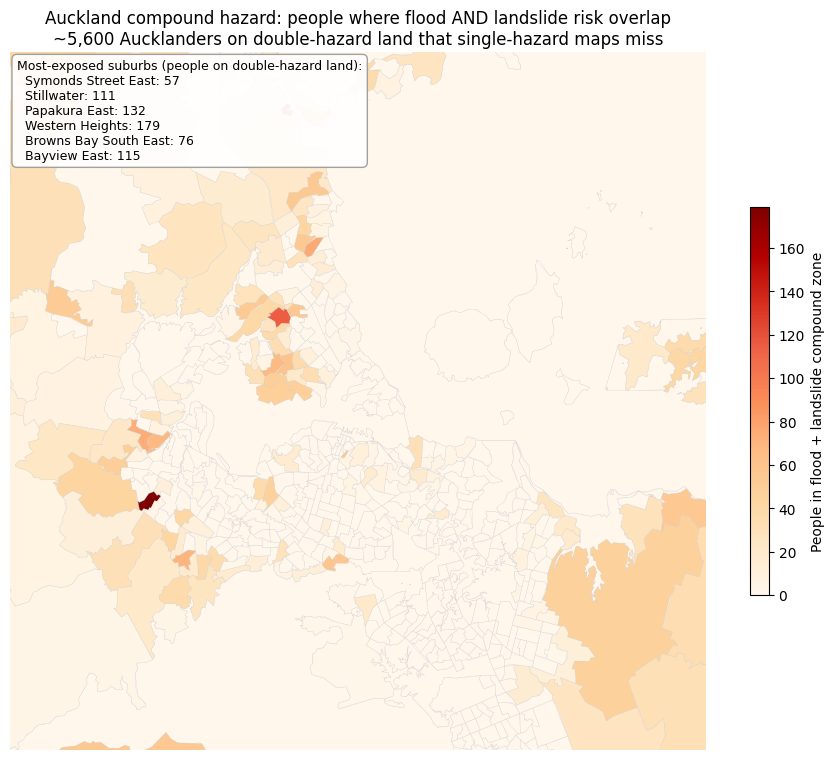

Saved.


In [13]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

compound = gpd.read_file("../data/processed/compound_hazard_zone.gpkg")
ranking = pd.read_csv("../outputs/compound_hazard_population.csv")

pop = gpd.read_file("../../05-wellington-seismic-access/data/raw/sa2_population.geojson")
pop = pop[["SA22023_V1_00_NAME", "geometry"]].rename(columns={"SA22023_V1_00_NAME":"sa2_name"})
pop = pop.to_crs("EPSG:2193")
pop["geometry"] = pop.geometry.simplify(80)

m = pop.merge(ranking, left_on="sa2_name", right_on="suburb", how="left")
m["population_in_compound_zone"] = m["population_in_compound_zone"].fillna(0)
m["area_km2"] = m.geometry.area / 1e6
m["density"] = m["population_in_compound_zone"] / m["area_km2"]

# Only real urban SA2s: drop giant rural polygons that distort the picture
sub = m[(m["population_in_compound_zone"] > 0) & (m["area_km2"] < 10)].copy()

# Tight crop around the dense cluster (weight by people so empties don't stretch it)
cen = sub.geometry.centroid
mx = (cen.x * sub["population_in_compound_zone"]).sum() / sub["population_in_compound_zone"].sum()
my = (cen.y * sub["population_in_compound_zone"]).sum() / sub["population_in_compound_zone"].sum()
d = ((cen.x - mx)**2 + (cen.y - my)**2)**0.5
core = sub[d <= d.quantile(0.75)]
bx0, by0, bx1, by1 = core.total_bounds
pad = 2500
view = m.cx[bx0-pad:bx1+pad, by0-pad:by1+pad]

fig, ax = plt.subplots(figsize=(9, 10))
view.plot(ax=ax, column="population_in_compound_zone", cmap="OrRd",
          linewidth=0.2, edgecolor="#ccc", legend=True,
          legend_kwds={"label":"People in flood + landslide compound zone", "shrink":0.4})
ax.set_xlim(bx0-pad, bx1+pad); ax.set_ylim(by0-pad, by1+pad)
ax.set_axis_off()

# Rank the callout list by DENSITY, urban only, so it names real at-risk suburbs
top6 = sub.sort_values("density", ascending=False).head(6)
lines = ["Most-exposed suburbs (people on double-hazard land):"]
for _, rr in top6.iterrows():
    lines.append(f"  {rr['sa2_name'].replace(' (Auckland)','')}: {rr['population_in_compound_zone']:.0f}")
ax.text(0.01, 0.99, "\n".join(lines), transform=ax.transAxes, va="top", ha="left",
        fontsize=9, bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="#999", alpha=0.92))

ax.set_title("Auckland compound hazard: people where flood AND landslide risk overlap\n"
             "~5,600 Aucklanders on double-hazard land that single-hazard maps miss",
             fontsize=12)
plt.tight_layout()
plt.savefig("../outputs/auckland_compound_hazard_map.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved.")